<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Multiple Linear Regression Analysis
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Econometrics - ECON 4750<br>
        <strong>Topic:</strong> From Simple to Multiple Regression<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Date:</strong> Summer 2025<br>
        <strong>Dataset:</strong> Wooldridge Wage1 (526 observations)<br>
        <strong>Research Question:</strong> What determines wage differences across workers?<br>
        <strong>Learning Objectives:</strong>
        <ul style="margin:5px 0; padding-left:20px;">
            <li>Understand the transition from simple to multiple regression</li>
            <li>Implement multiple regression using statsmodels</li>
            <li>Interpret partial regression coefficients (ceteris paribus effects)</li>
            <li>Compare simple vs multiple regression results</li>
            <li>Understand omitted variable bias</li>
        </ul>
    </div>
</div>

---

## 1. Introduction and Data Setup

**Economic Motivation:**

In reality, wages depend on multiple factors simultaneously - education, experience, ability, gender, location, etc. Simple regression ignoring these factors can lead to **omitted variable bias**, giving us misleading estimates of individual effects.

In this notebook, we'll estimate a wage equation using multiple regression.

In [1]:
# ===================================== #
#     Environment Setup
# ===================================== #

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Set professional plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("*"*52)
print("Environment Setup".center(52))
%reload_ext watermark
%watermark -iv -v -ud -a "Dr. Saad Laouadi"
print("*"*52)

****************************************************
                 Environment Setup                  
Author: Dr. Saad Laouadi

Last updated: 2025-06-15

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.1.0

seaborn    : 0.13.2
numpy      : 2.3.0
matplotlib : 3.10.0
statsmodels: 0.14.4
scipy      : 1.15.3
pandas     : 2.2.3

****************************************************


In [2]:
print("=== WAGE DETERMINANTS ANALYSIS ===")
print("Multiple Linear Regression Implementation")
print("Wooldridge Dataset: wage1.csv")

# Load and examine the dataset
wage_data = pd.read_stata("../../datasets/WAGE1.DTA")

print("Dataset Overview:")
print("=" * 50)

print(f"Sample size: {len(wage_data):,} observations")
print(f"Variables available: {len(wage_data.columns)} variables")
print(f"Key variables: {list(wage_data.columns[:10])}")

=== WAGE DETERMINANTS ANALYSIS ===
Multiple Linear Regression Implementation
Wooldridge Dataset: wage1.csv
Dataset Overview:
Sample size: 526 observations
Variables available: 24 variables
Key variables: ['wage', 'educ', 'exper', 'tenure', 'nonwhite', 'female', 'married', 'numdep', 'smsa', 'northcen']


In [3]:
# Display first observations
print(f"\nFirst 8 observations:")
print(wage_data[['wage', 'educ', 'exper']].head(8))


First 8 observations:
    wage  educ  exper
0   3.10    11      2
1   3.24    12     22
2   3.00    11      2
3   6.00     8     44
4   5.30    12      7
5   8.75    16      9
6  11.25    18     15
7   5.00    12      5


In [4]:
# Data quality check
missing_values = wage_data.isnull().sum().sum()
print(f"\nData Quality:")
print(f"Missing values: {missing_values}")


Data Quality:
Missing values: 0


---

## 2. Exploratory Data Analysis

**Focus Variables for this Analysis:**
- **wage**: hourly wage in dollars (dependent variable)
- **educ**: years of education (key explanatory variable)
- **exper**: years of work experience (control variable)

In [5]:
# Select variables for analysis
analysis_vars = ['wage', 'educ', 'exper']
data = wage_data[analysis_vars].copy()

# Comprehensive descriptive statistics
print("Descriptive Statistics:")
print("=" * 50)
desc_stats = data.describe()
print(desc_stats.round(3))

Descriptive Statistics:
          wage     educ    exper
count  526.000  526.000  526.000
mean     5.896   12.563   17.017
std      3.693    2.769   13.572
min      0.530    0.000    1.000
25%      3.330   12.000    5.000
50%      4.650   12.000   13.500
75%      6.880   14.000   26.000
max     24.980   18.000   51.000


### 2.1 Distribution Analysis

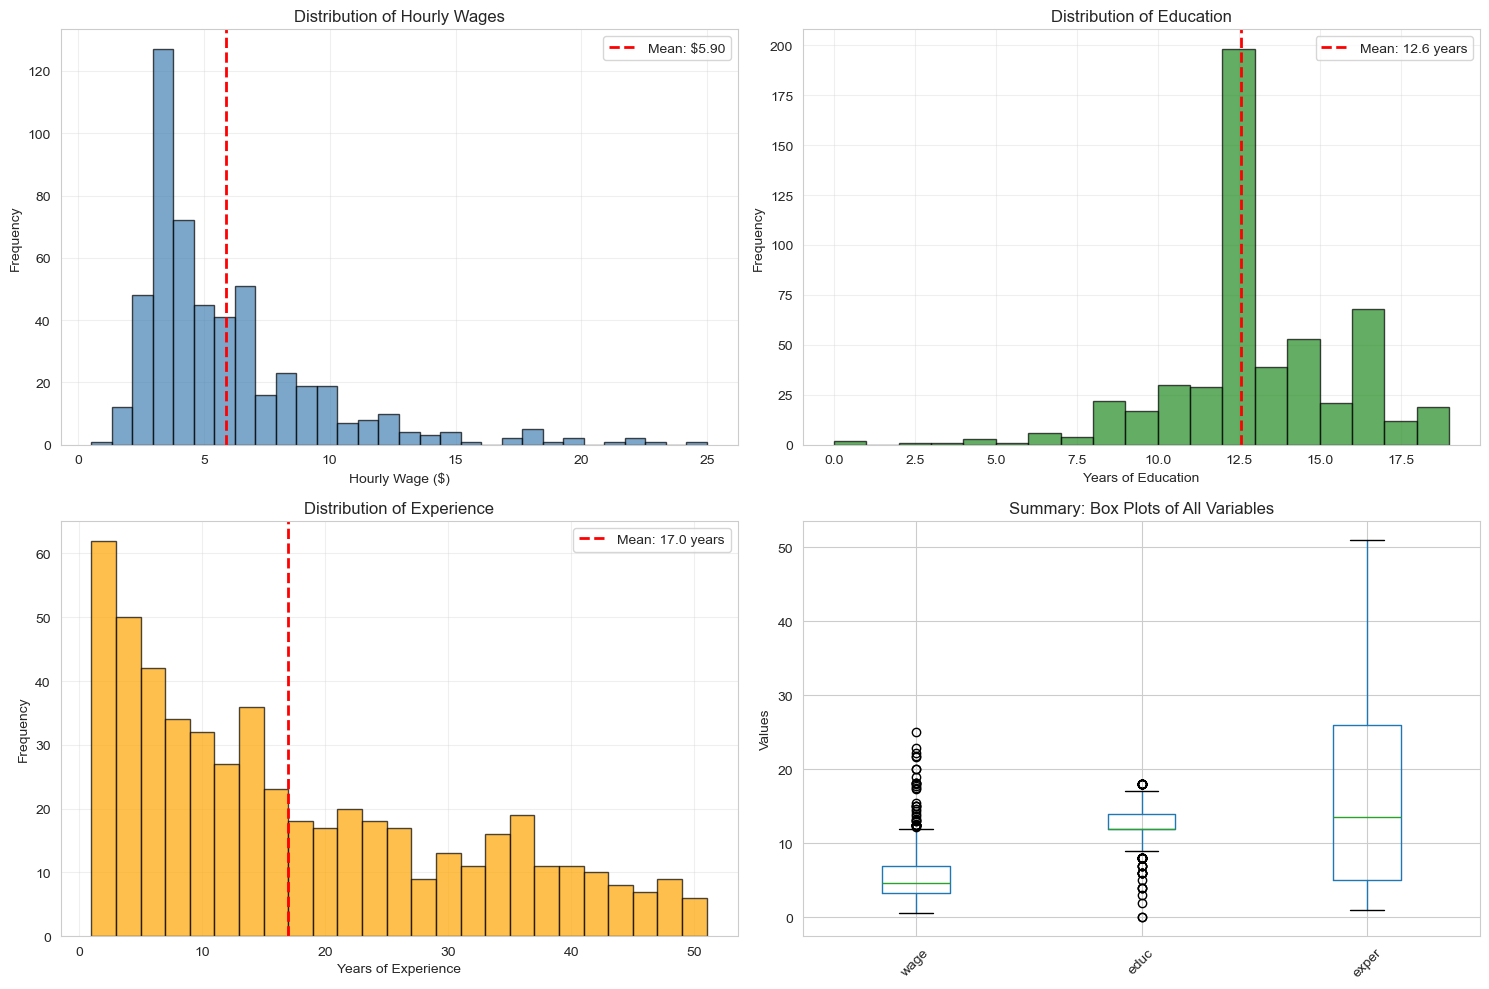

In [6]:
# Create professional distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Wage distribution
axes[0,0].hist(data['wage'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,0].axvline(data['wage'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${data["wage"].mean():.2f}')
axes[0,0].set_xlabel('Hourly Wage ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Hourly Wages')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Education distribution
axes[0,1].hist(data['educ'], bins=range(int(data['educ'].min()), int(data['educ'].max())+2), 
               alpha=0.7, color='forestgreen', edgecolor='black')
axes[0,1].axvline(data['educ'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["educ"].mean():.1f} years')
axes[0,1].set_xlabel('Years of Education')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Education')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Experience distribution
axes[1,0].hist(data['exper'], bins=25, alpha=0.7, color='orange', edgecolor='black')
axes[1,0].axvline(data['exper'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["exper"].mean():.1f} years')
axes[1,0].set_xlabel('Years of Experience')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Experience')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Box plot summary
data.boxplot(ax=axes[1,1])
axes[1,1].set_title('Summary: Box Plots of All Variables')
axes[1,1].set_ylabel('Values')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

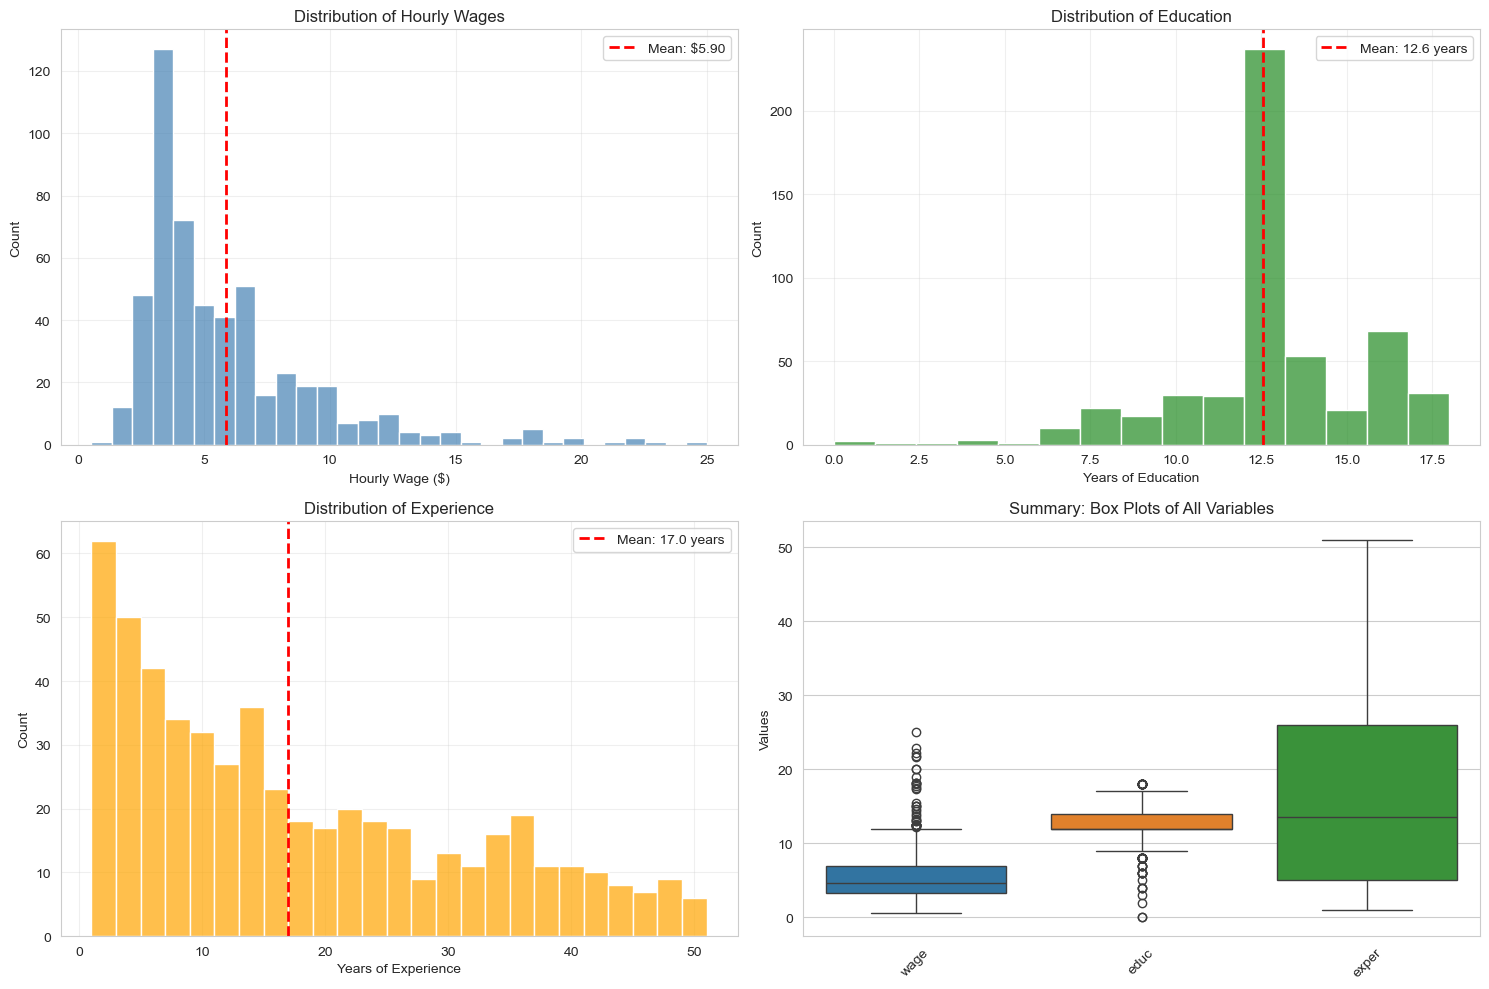

In [7]:
# Create professional distribution plots using seaborn
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Wage distribution
sns.histplot(data=data, x='wage', bins=30, alpha=0.7, color='steelblue', ax=ax1)
ax1.axvline(data['wage'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: ${data["wage"].mean():.2f}')
ax1.set_xlabel('Hourly Wage ($)')
ax1.set_title('Distribution of Hourly Wages')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Education distribution
sns.histplot(data=data, x='educ', bins=15, alpha=0.7, color='forestgreen', ax=ax2)
ax2.axvline(data['educ'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {data["educ"].mean():.1f} years')
ax2.set_xlabel('Years of Education')
ax2.set_title('Distribution of Education')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Experience distribution
sns.histplot(data=data, x='exper', bins=25, alpha=0.7, color='orange', ax=ax3)
ax3.axvline(data['exper'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {data["exper"].mean():.1f} years')
ax3.set_xlabel('Years of Experience')
ax3.set_title('Distribution of Experience')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Box plot summary
sns.boxplot(data=data, ax=ax4)
ax4.set_title('Summary: Box Plots of All Variables')
ax4.set_ylabel('Values')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

### 2.2 Relationship Analysis

Pairwise Relationships Analysis:


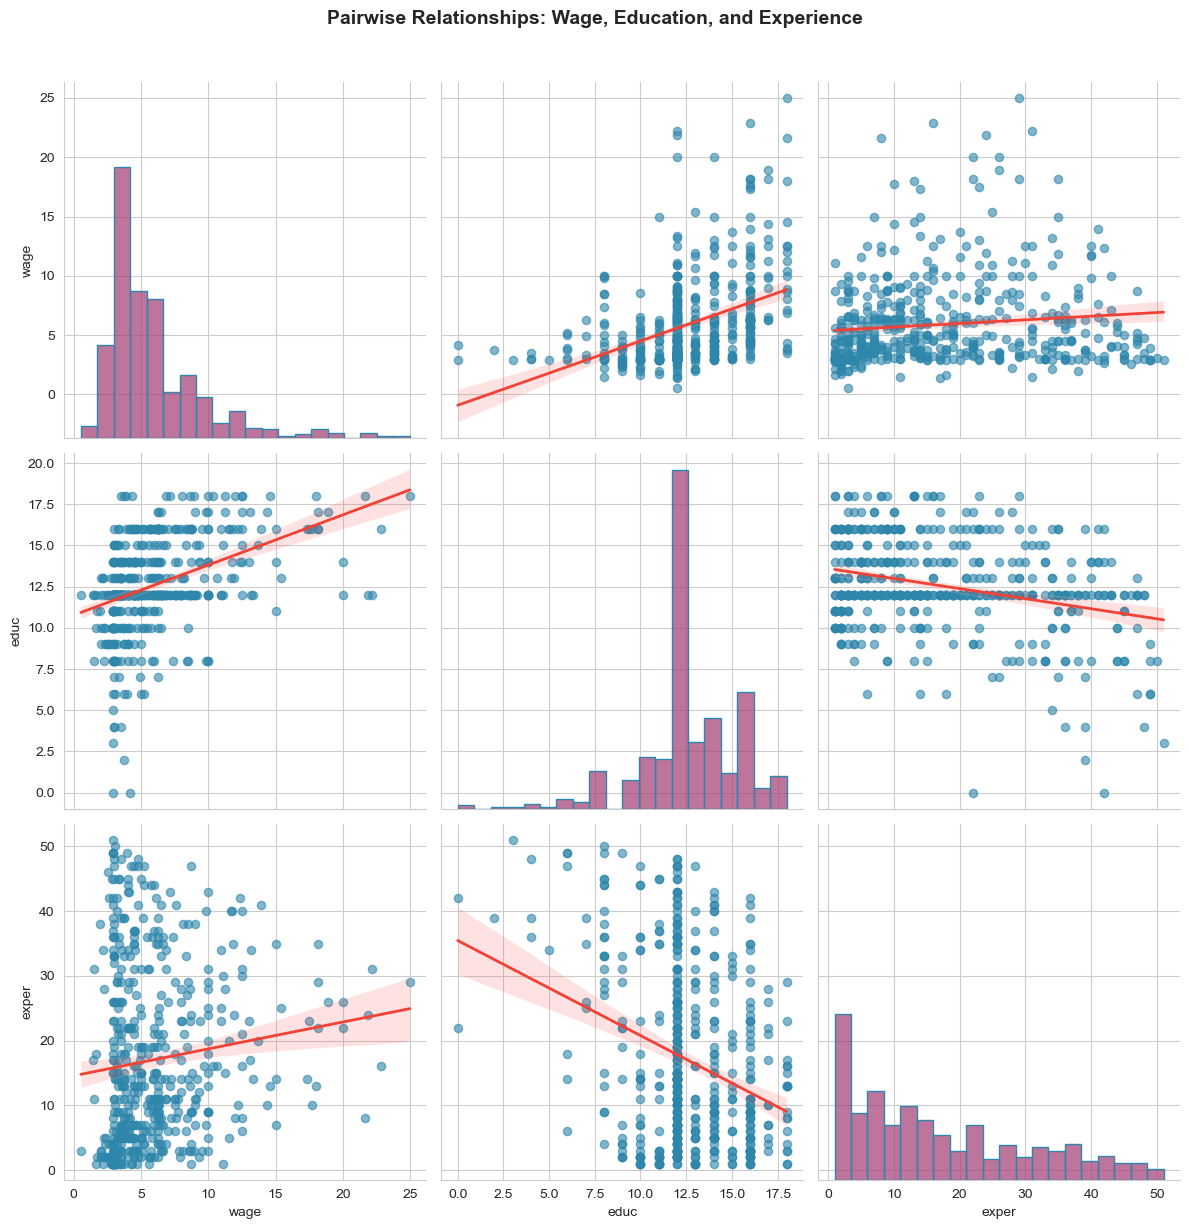

In [8]:
# Professional pairwise relationship analysis with modern colors
print("Pairwise Relationships Analysis:")
print("=" * 50)

pairplot_fig = sns.pairplot(data, 
                           kind='reg',
                           height=4,
                           aspect=1, 
                           diag_kind='hist',
                           plot_kws={'scatter_kws': {'alpha': 0.6, 's': 35, 'color': '#2E86AB'}, 
                                   'line_kws': {'color': '#F24236', 'linewidth': 2}},
                           diag_kws={'alpha': 0.7, 'bins': 20, 'edgecolor': '#2E86AB', 'color': '#A23B72'})

pairplot_fig.fig.suptitle('Pairwise Relationships: Wage, Education, and Experience', 
                         y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Correlation analysis
print("Correlation Matrix:")
print("=" * 30)
correlation_matrix = data.corr()
print(correlation_matrix.round(3))

Correlation Matrix:
        wage   educ  exper
wage   1.000  0.406  0.113
educ   0.406  1.000 -0.300
exper  0.113 -0.300  1.000


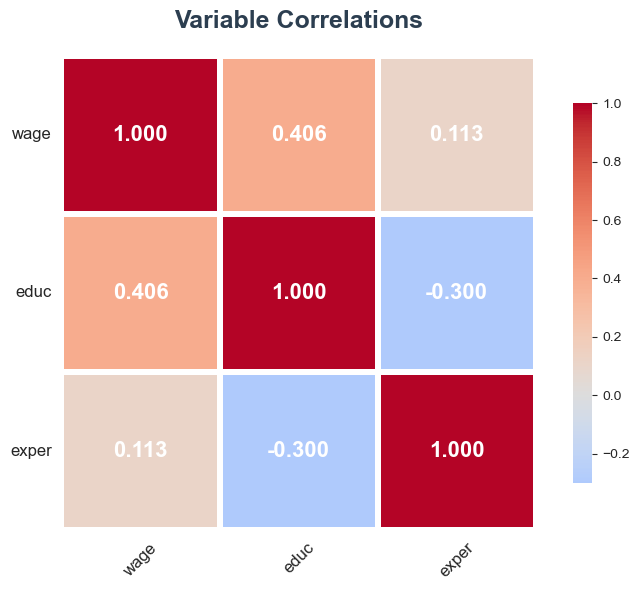

In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 6))

# Create mask for upper triangle
# mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create elegant heatmap
sns.heatmap(correlation_matrix, 
            # mask=mask, 
            annot=True, 
            cmap='coolwarm',  # More appealing color scheme
            center=0,
            square=True, 
            fmt='.3f',
            annot_kws={'size': 16, 'weight': 'bold', 'color': 'white'},
            cbar_kws={'shrink': 0.8},
            linewidths=3,
            linecolor='white')

# Simple, clean styling
plt.title('Variable Correlations', fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

---

## 3. Regression Analysis: Simple vs Multiple

### 3.1 Simple Regression Baselines

In [11]:
print("STEP 1: Simple Regression Analysis")
print("=" * 50)
print("Understanding individual relationships before multiple regression")

# Simple regression: Wage on Education
simple_educ = smf.ols('wage ~ educ', data=data).fit()
print(simple_educ.summary())

STEP 1: Simple Regression Analysis
Understanding individual relationships before multiple regression
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           2.78e-22
Time:                        20:29:00   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [12]:
# Simple regression: Wage on Experience
simple_exper = smf.ols('wage ~ exper', data=data).fit()
print(simple_exper.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     6.766
Date:                Sun, 15 Jun 2025   Prob (F-statistic):            0.00955
Time:                        20:29:00   Log-Likelihood:                -1429.7
No. Observations:                 526   AIC:                             2863.
Df Residuals:                     524   BIC:                             2872.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3733      0.257     20.908      0.0

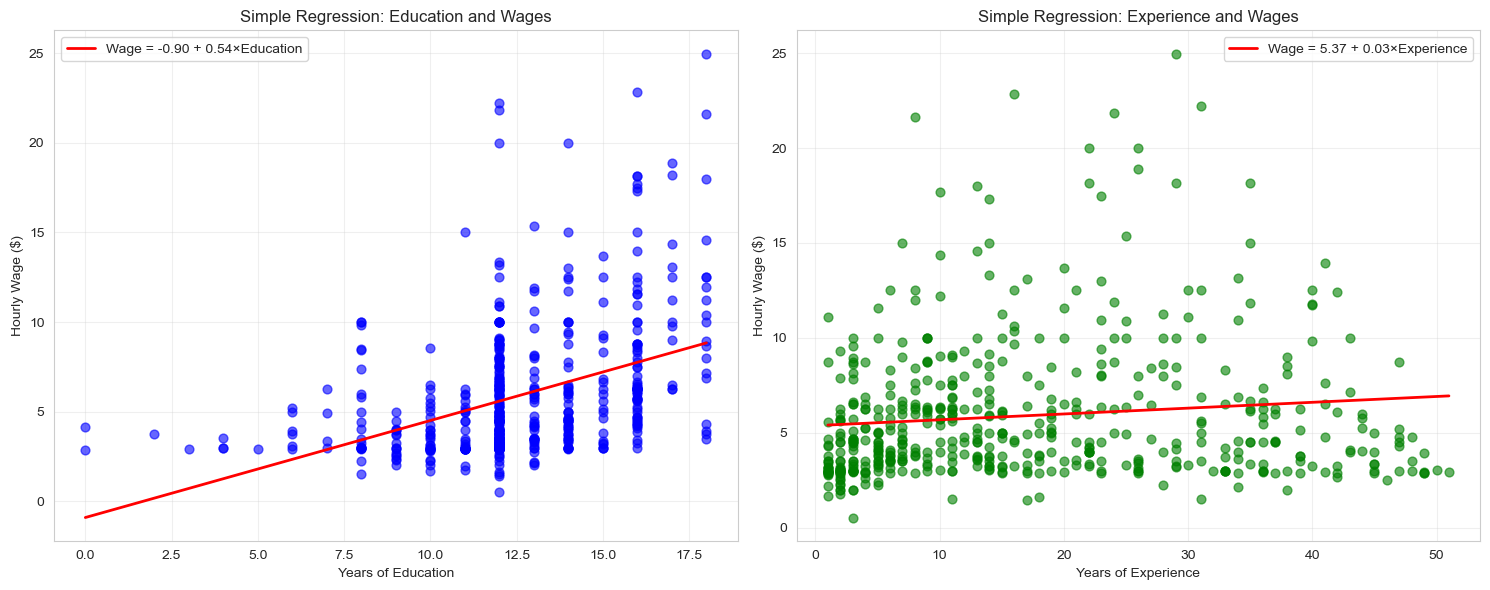

In [13]:
# Visualize simple regressions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Education-Wage relationship
ax1.scatter(data['educ'], data['wage'], alpha=0.6, color='blue', s=40)
x_educ = np.linspace(data['educ'].min(), data['educ'].max(), 100)

y_pred_educ = simple_educ.params['Intercept'] + simple_educ.params['educ'] * x_educ

ax1.plot(x_educ, y_pred_educ, 'r-', linewidth=2, 
         label=f'Wage = {simple_educ.params["Intercept"]:.2f} + {simple_educ.params["educ"]:.2f}×Education')
ax1.set_xlabel('Years of Education')
ax1.set_ylabel('Hourly Wage ($)')
ax1.set_title('Simple Regression: Education and Wages')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Experience-Wage relationship
ax2.scatter(data['exper'], data['wage'], alpha=0.6, color='green', s=40)
x_exper = np.linspace(data['exper'].min(), data['exper'].max(), 100)
y_pred_exper = simple_exper.params['Intercept'] + simple_exper.params['exper'] * x_exper
ax2.plot(x_exper, y_pred_exper, 'r-', linewidth=2,
         label=f'Wage = {simple_exper.params["Intercept"]:.2f} + {simple_exper.params["exper"]:.2f}×Experience')
ax2.set_xlabel('Years of Experience')
ax2.set_ylabel('Hourly Wage ($)')
ax2.set_title('Simple Regression: Experience and Wages')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Multiple Regression Analysis

In [14]:
print("\nSTEP 2: Multiple Regression Analysis")
print("=" * 50)
print("Estimating partial effects with multiple explanatory variables")

# Estimate multiple regression
multiple_model = smf.ols('wage ~ educ + exper', data=data).fit()

print(f"\nMultiple Regression Model: WAGE = β₀ + β₁EDUC + β₂EXPER + ε")
print(f"\nComplete Regression Results:")
print(multiple_model.summary())


STEP 2: Multiple Regression Analysis
Estimating partial effects with multiple explanatory variables

Multiple Regression Model: WAGE = β₀ + β₁EDUC + β₂EXPER + ε

Complete Regression Results:
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     75.99
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           1.07e-29
Time:                        20:29:00   Log-Likelihood:                -1366.0
No. Observations:                 526   AIC:                             2738.
Df Residuals:                     523   BIC:                             2751.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 c

### Model Diagnosis

In [15]:
# Get residuals and fitted values
residuals = multiple_model.resid
fitted_values = multiple_model.fittedvalues
standardized_residuals = multiple_model.resid_pearson

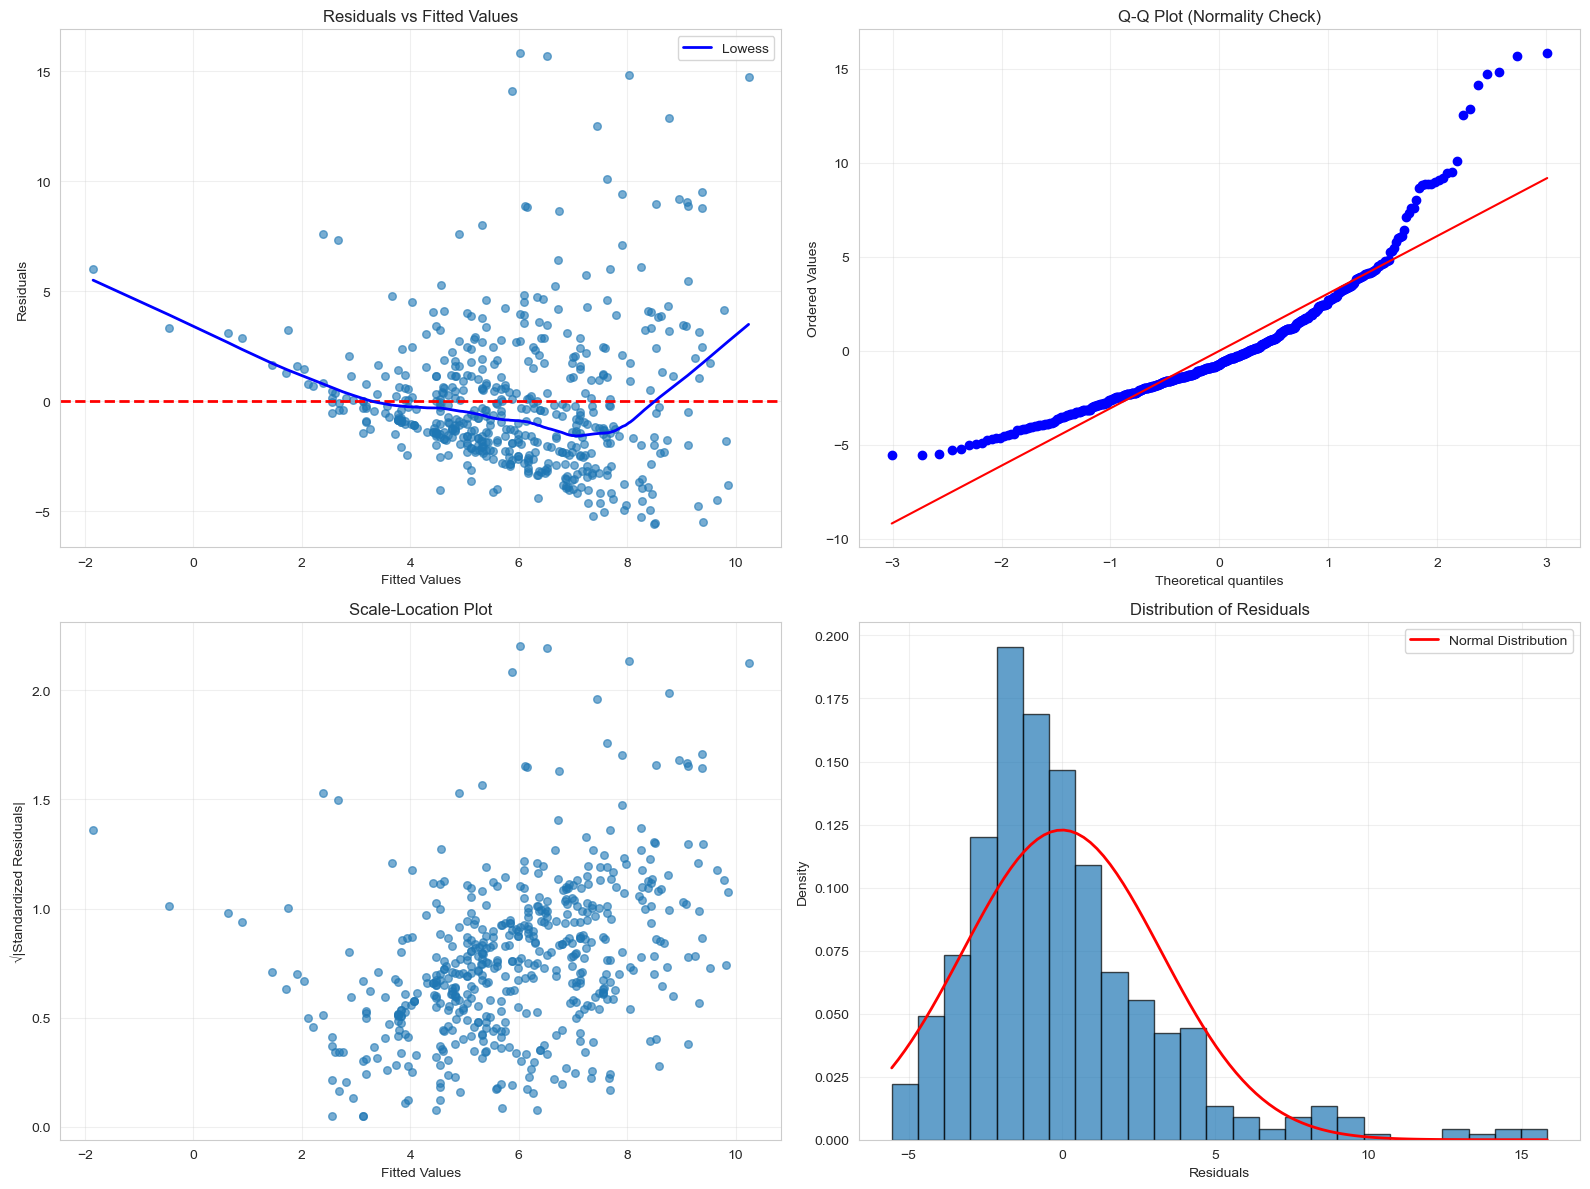

In [16]:
# Create comprehensive diagnostic plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Residuals vs Fitted
ax1.scatter(fitted_values, residuals, alpha=0.6, s=30)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Add lowess line to detect patterns
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_line = lowess(residuals, fitted_values, frac=0.3)
ax1.plot(lowess_line[:, 0], lowess_line[:, 1], color='blue', linewidth=2, label='Lowess')
ax1.legend()

# Plot 2: Q-Q plot for normality
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)')
ax2.grid(True, alpha=0.3)

# Plot 3: Scale-Location plot
sqrt_abs_resid = np.sqrt(np.abs(standardized_residuals))
ax3.scatter(fitted_values, sqrt_abs_resid, alpha=0.6, s=30)
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('√|Standardized Residuals|')
ax3.set_title('Scale-Location Plot')
ax3.grid(True, alpha=0.3)

# Plot 4: Histogram of residuals with normal overlay
ax4.hist(residuals, bins=25, density=True, alpha=0.7, edgecolor='black')
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax4.plot(x_norm, stats.norm.pdf(x_norm, np.mean(residuals), np.std(residuals)), 
         'r-', linewidth=2, label='Normal Distribution')
ax4.set_xlabel('Residuals')
ax4.set_ylabel('Density')
ax4.set_title('Distribution of Residuals')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()